# 08 — Hourly Prediction Demo

展示 `predict_hourly.py` 在 2023-12-31 18:00 holdout hour 的輸出。這是單一歷史回測，不是即時預測。

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
predictions = pd.read_csv(ROOT / 'results/example_hourly_predictions.csv')
metadata = json.loads((ROOT / 'models/hist_gradient_boosting_weather.metadata.json').read_text())
predictions.head(10)

,prediction_rank,target_time,station_name,predicted_borrow_count,actual_borrow_count,absolute_error
0,1,2023-12-31T18:00:00+08:00,捷運公館站(2號出口),27.827136,24.0,3.827136
1,2,2023-12-31T18:00:00+08:00,捷運芝山站(2號出口)_1,18.136928,20.0,1.863072
2,3,2023-12-31T18:00:00+08:00,捷運龍山寺站(1號出口),16.904114,22.0,5.095886
3,4,2023-12-31T18:00:00+08:00,捷運中山國中站,16.193207,13.0,3.193207
4,5,2023-12-31T18:00:00+08:00,捷運科技大樓站,16.030178,15.0,1.030178
5,6,2023-12-31T18:00:00+08:00,捷運公館站(3號出口),13.137943,6.0,7.137943
6,7,2023-12-31T18:00:00+08:00,捷運北門站(3號出口),11.883451,6.0,5.883451
7,8,2023-12-31T18:00:00+08:00,捷運六張犁站,10.677220,16.0,5.322780
8,9,2023-12-31T18:00:00+08:00,捷運南京三民站(1號出口),10.204143,13.0,2.795857
9,10,2023-12-31T18:00:00+08:00,捷運圓山站(1號出口),9.986040,5.0,4.986040


## Model bundle
Metadata 固定模型範圍、特徵 schema、套件版本與 artifact checksum。

In [2]:
pd.Series({
    'model_name': metadata['model_name'],
    'stations': metadata['selected_station_count'],
    'trained_through': metadata['trained_through'],
    'features': len(metadata['feature_columns']),
    'sha256_prefix': metadata['artifact_sha256'][:12],
})

model_name         hist_gradient_boosting_weather
stations                                      100
trained_through         2023-11-30T23:00:00+08:00
features                                       18
sha256_prefix                        18401defbc0e
dtype: object

## 單一小時結果
單點誤差用於檢查介面，不能取代整月 holdout 評估。

In [3]:
summary = pd.Series({
    'target_time': predictions['target_time'].iloc[0],
    'stations': len(predictions),
    'single_hour_mae': predictions['absolute_error'].mean(),
    'average_prediction': predictions['predicted_borrow_count'].mean(),
    'average_actual': predictions['actual_borrow_count'].mean(),
})
summary

target_time           2023-12-31T18:00:00+08:00
stations                                    100
single_hour_mae                        2.471782
average_prediction                     5.788261
average_actual                             5.48
dtype: object

/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_41298/1337728531.py:7: UserWarning: Glyph 25463 (\N{CJK UNIFIED IDEOGRAPH-6377}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_41298/1337728531.py:7: UserWarning: Glyph 36939 (\N{CJK UNIFIED IDEOGRAPH-904B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_41298/1337728531.py:7: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_41298/1337728531.py:7: UserWarning: Glyph 23665 (\N{CJK UNIFIED IDEOGRAPH-5C71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97v73dhf2r3q6_zm00000gn/T/ipykernel_41298/1337728531.py:7: UserWarning: Glyph 22500 (\N{CJK UNIFIED IDEOGRAPH-57E4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ks/w1ns79m97

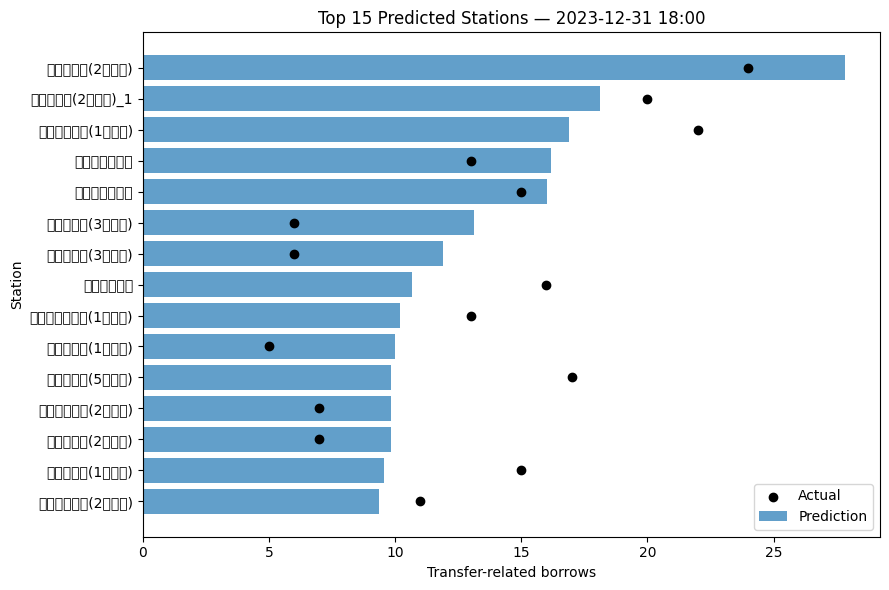

In [4]:
top = predictions.head(15).sort_values('predicted_borrow_count')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['station_name'], top['predicted_borrow_count'], alpha=0.7, label='Prediction')
ax.scatter(top['actual_borrow_count'], top['station_name'], color='black', label='Actual')
ax.set(title='Top 15 Predicted Stations — 2023-12-31 18:00', xlabel='Transfer-related borrows', ylabel='Station')
ax.legend()
plt.tight_layout()
plt.show()

## 解讀限制

輸出是 100 個研究站點的 hourly transfer-related demand ranking。它不能直接轉換成補車數量，也不是 30／60 分鐘後的可借車數。